# Selected OV Doubles

## UCCSD 6e6o S1 Errors

In [1]:
%load_ext autoreload
%autoreload 2

import sys

import numpy as np
import pandas as pd

from config import PROJECT_ROOT, PROCESSED_DATAFRAMES_DIR
from notebook_utils.chem import CHEMICAL_ACCURACY
from notebook_utils.general import save_figure
from notebook_utils.graphs import plot_ov_doubles_s1_error_scatter, show_scrollable_figs

sys.path.append(str(PROJECT_ROOT / "scripts"))
from script_utils import MOLECULE_NAMES

SV_DATAFRAME_PATH = PROCESSED_DATAFRAMES_DIR / "sv_qse_data.pkl"
OV_DOUBLES_DATAFRAME_PATH = PROCESSED_DATAFRAMES_DIR / "sv_qse_ov_doubles_data.pkl"
OVERLAP_THRESHOLD = 1e-8
CHEMICAL_ACCURACY_MHA = 1000 * CHEMICAL_ACCURACY

In [2]:
df_sv_singlet = pd.read_pickle(SV_DATAFRAME_PATH).query(
    "active_space == '6e6o' and ansatz == 'UCCSD' and expansion == 'singlet'"
).copy()
df_sv_ov_doubles = pd.read_pickle(OV_DOUBLES_DATAFRAME_PATH).query(
    "active_space == '6e6o' and ansatz == 'UCCSD' and expansion == 'select_ov_doubles'"
).copy()

print(f"Singles-only rows: {len(df_sv_singlet)}")
print(f"OV-doubles rows: {len(df_sv_ov_doubles)}")

Singles-only rows: 28
OV-doubles rows: 28


In [3]:
def get_s1_error(H, S, exact_energies):
    eigenvalues, eigenvectors = np.linalg.eigh(np.asarray(S, dtype=complex))
    retained = eigenvalues > OVERLAP_THRESHOLD
    transform = eigenvectors[:, retained] / np.sqrt(eigenvalues[retained])
    qse_energies = np.linalg.eigvalsh(transform.conj().T @ np.asarray(H) @ transform)
    return 1000 * abs(qse_energies[1] - exact_energies[1])

singles_rows = df_sv_singlet.set_index("molecule")
ov_doubles_rows = df_sv_ov_doubles.set_index("molecule")
comparison_records = []

for molecule in MOLECULE_NAMES:
    singles_row = singles_rows.loc[molecule]
    ov_doubles_row = ov_doubles_rows.loc[molecule]
    comparison_records.append({
        "molecule": molecule,
        "singles_only_mHa": get_s1_error(
            singles_row["H"], singles_row["S"], singles_row["pyscf_casci_energies"]
        ),
        "ov_doubles_mHa": get_s1_error(
            ov_doubles_row["H"], ov_doubles_row["S"], ov_doubles_row["pyscf_casci_energies"]
        ),
    })

df_s1_ov_doubles_comparison = pd.DataFrame(comparison_records)
display(df_s1_ov_doubles_comparison)

,molecule,singles_only_mHa,ov_doubles_mHa
0,Acetamide,0.357628,0.132294
1,Acetone,1.080174,0.134521
2,Adenine,14.391019,2.040980
3,Benzene,70.901844,2.685136
4,Benzoquinone,23.772745,0.863360
5,Butadiene,138.928074,1.865470
6,Cyclopentadiene,83.961785,0.953002
7,Cyclopropene,1.715776,0.444549
8,Cytosine,28.738630,3.526151
9,Ethene,4.928838,0.065095



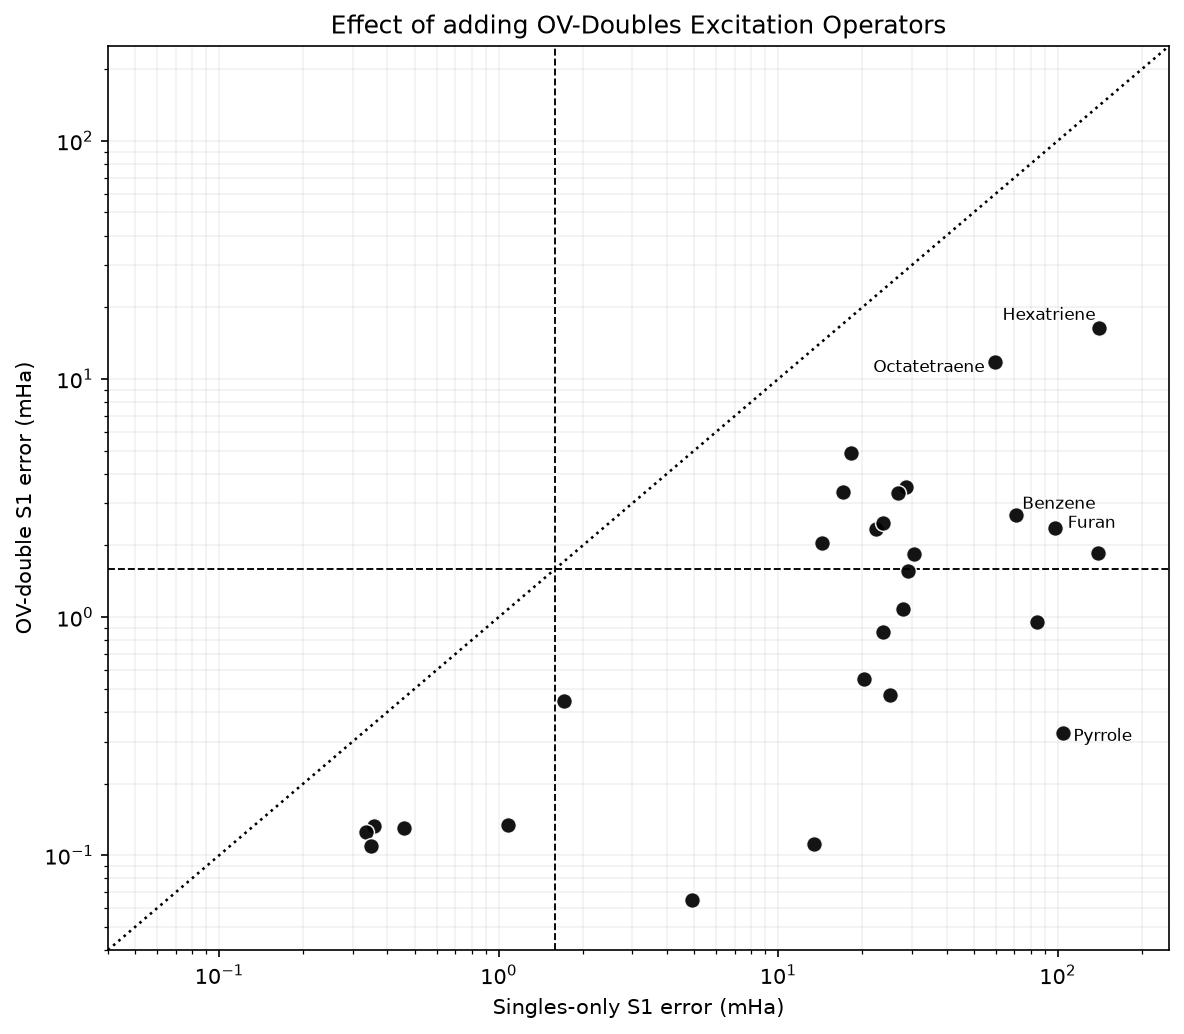

In [4]:
figure = plot_ov_doubles_s1_error_scatter(df_s1_ov_doubles_comparison)
save_figure(figure, "scaling_future_work", "ov_doubles_s1_error_comparison")
show_scrollable_figs([figure])